# Проект для «Викишоп»

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. 

Обучите модель классифицировать комментарии на позитивные и негативные. В вашем распоряжении набор данных с разметкой о токсичности правок.

Постройте модель со значением метрики качества *F1* не меньше 0.75. 

**Инструкция по выполнению проекта**

1. Загрузите и подготовьте данные.
2. Обучите разные модели. 
3. Сделайте выводы.

Для выполнения проекта применять *BERT* необязательно, но вы можете попробовать.

**Описание данных**

Данные находятся в файле `toxic_comments.csv`. Столбец *text* в нём содержит текст комментария, а *toxic* — целевой признак.

## Подготовка

In [1]:
import pandas as pd
import numpy as np
import nltk
import re
import matplotlib.pyplot as plt
from tqdm import tqdm
from pymystem3 import Mystem

from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer 
from sklearn.utils import shuffle
from sklearn.metrics import precision_score, recall_score, accuracy_score, roc_auc_score, roc_curve

from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem import WordNetLemmatizer 
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

pd.set_option('display.max_colwidth', 1000)

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/jovyan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
df = pd.read_csv('/datasets/toxic_comments.csv')

In [3]:
df.head()

,Unnamed: 0,text,toxic
0,0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",0
1,1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0
2,2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",0
3,3,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nThere appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It's listed in the relevant form eg Wikipedia:Good_article_nominations#Transport """,0
4,4,"You, sir, are my hero. Any chance you remember what page that's on?",0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  159292 non-null  int64 
 1   text        159292 non-null  object
 2   toxic       159292 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.6+ MB


Пропусков нет 

In [5]:
df.duplicated().sum()

0

Дубликатов тоже нет

Посмотрим на соотношение токсичных и не токсичных комментариев

In [6]:
df['toxic'].value_counts()

0    143106
1     16186
Name: toxic, dtype: int64

In [7]:
ratio = df['toxic'].value_counts()[0] / df['toxic'].value_counts()[1]
ratio

8.841344371679229

    Классы несбалансированы. Отношение примерно 1 : 8.8 

    Проведем поиск лучшего способа балансировки:

            1) Изменение весов в модели обучения
            2) Ресемплирование с уменьшением класса 0 (с увеличением класса 1 не будем использовать из-за большого набора данных)

Подготовим признаки и целевой признак

In [8]:
%%time

m = Mystem()

def text_lemmatize(text):
    text = text.lower()
    lemm_text = "".join(m.lemmatize(text))
    clear_text = re.sub(r'[^a-zA-Z]', ' ', lemm_text) 
    return " ".join(clear_text.split())

df['lemm_text'] = df['text'].apply(text_lemmatize)
df = df.drop(['text'], axis=1)

del m

CPU times: user 42.3 s, sys: 8.48 s, total: 50.7 s
Wall time: 1min 48s


Разобьем выборки по отношению 3/1/1. 

In [9]:
target = df['toxic']
features = df.drop(['toxic'], axis=1)

features_train, features_valid, target_train, target_valid = train_test_split(features, 
                                                                              target, 
                                                                              test_size=0.4, 
                                                                              random_state=12082020)
features_valid, features_test, target_valid, target_test = train_test_split(features_valid, 
                                                                            target_valid, 
                                                                            test_size=0.5,
                                                                            random_state=12082020)

nltk.download('stopwords')
stopwords = set(nltk_stopwords.words('english'))

count_tf_idf = TfidfVectorizer(stop_words=stopwords)

features_train = count_tf_idf.fit_transform(features_train['lemm_text'].values.astype('U'))
features_valid = count_tf_idf.transform(features_valid['lemm_text'].values.astype('U'))
features_test = count_tf_idf.transform(features_test['lemm_text'].values.astype('U'))

print("Обучающая выборка", features_train.shape)
print("Валидационная выборка", features_valid.shape)
print("Тестовая выборка", features_test.shape)

cv_counts = 3 #кол-во кроссвалидаций

[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Обучающая выборка (95575, 126563)
Валидационная выборка (31858, 126563)
Тестовая выборка (31859, 126563)


In [10]:
%%time

classificator = LogisticRegression()
train_f1 = cross_val_score(classificator, 
                      features_train, 
                      target_train, 
                      cv=cv_counts, 
                      scoring='f1').mean()
print('F1 на CV', train_f1)

F1 на CV 0.6739107720811951
CPU times: user 50.3 s, sys: 58 s, total: 1min 48s
Wall time: 1min 48s


**Изменение весов в модели обучения**

In [11]:
%%time

dict_classes={0:1, 1:ratio}
classificator = LogisticRegression(class_weight=dict_classes)
train_f1_ballanced = cross_val_score(classificator, 
                                    features_train, 
                                    target_train, 
                                    cv=cv_counts, 
                                    scoring='f1').mean()

print('F1 на CV с балансированными классами', train_f1_ballanced)

F1 на CV с балансированными классами 0.754446389380124
CPU times: user 57.8 s, sys: 1min 4s, total: 2min 2s
Wall time: 2min 2s


In [12]:
%%time

classificator = LogisticRegression(class_weight='balanced')
train_f1_balanced = cross_val_score(classificator, 
                                    features_train, 
                                    target_train, 
                                    cv=cv_counts, 
                                    scoring='f1').mean()
print('F1 на CV с балансированными классами', train_f1_ballanced)

F1 на CV с балансированными классами 0.754446389380124
CPU times: user 32.1 s, sys: 36 s, total: 1min 8s
Wall time: 1min 8s


Как видно на обучающей выборке F1-мера увеличилась. Была примерно 0,673 - стала 0,755

**Ресемплирование с уменьшением класса 0**

In [13]:
toxic_train = df.iloc[target_train.index]
target_train_zero = toxic_train[toxic_train['toxic'] == 0]['toxic']
target_train_one = toxic_train[toxic_train['toxic'] == 1]['toxic']

In [14]:
target_train_zero_downsample = target_train_zero.sample(target_train_one.shape[0],
                                                                    random_state=123456)
target_train_downsample = pd.concat([target_train_zero_downsample, target_train_one])

features_train_downsample = df.iloc[target_train_downsample.index]
features_train_downsample, target_train_downsample = shuffle(features_train_downsample,
                                                             target_train_downsample,
                                                             random_state=123456)
features_train_downsample = count_tf_idf.transform(features_train_downsample['lemm_text']
                                                   .values.astype('U'))
del count_tf_idf
del stopwords

In [15]:
classificator = LogisticRegression()
train_f1_downsampled = cross_val_score(classificator,
                      features_train_downsample, 
                      target_train_downsample, 
                      cv=cv_counts, 
                      scoring='f1').mean()
print('F1 на CV с уменьшением классов', train_f1_downsampled)

F1 на CV с уменьшением классов 0.8761597055241004


Таким образом, F1 сильно увеличилась.

Построим ROC-AUC графики

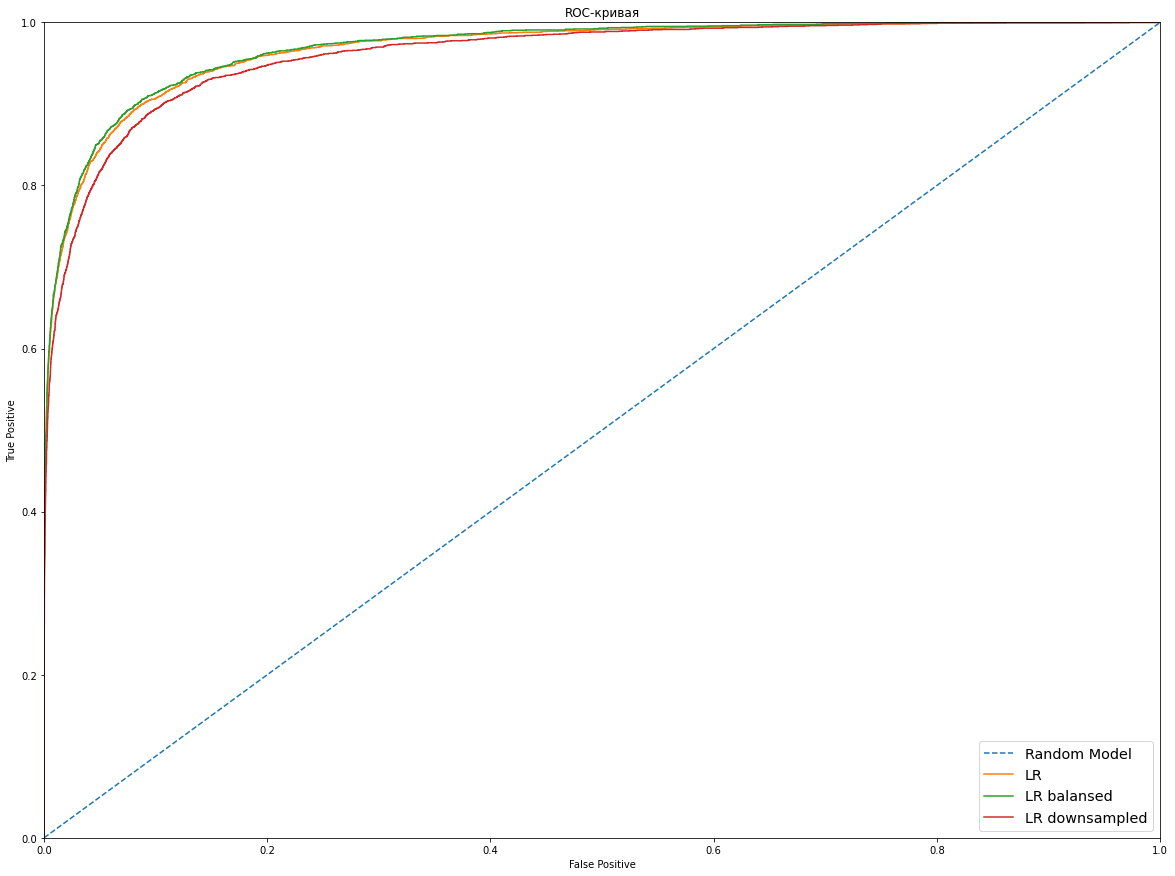

In [16]:
plt.figure(figsize=[20,15])
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Model')

classificator = LogisticRegression()
classificator.fit(features_train, target_train)
probabilities_valid = classificator.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]
fpr, tpr, thresholds = roc_curve(target_valid, probabilities_one_valid)
auc_roc = roc_auc_score(target_valid, probabilities_one_valid)
valid_f1 = f1_score(target_valid, classificator.predict(features_valid))
plt.plot(fpr, tpr, label='LR')

classificator = LogisticRegression(class_weight=dict_classes)
classificator.fit(features_train, target_train)
probabilities_valid = classificator.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]
fpr, tpr, thresholds = roc_curve(target_valid, probabilities_one_valid)
auc_roc_balanced = roc_auc_score(target_valid, probabilities_one_valid)
valid_f1_balanced = f1_score(target_valid, classificator.predict(features_valid))
plt.plot(fpr, tpr, label='LR balansed')

classificator = LogisticRegression()
classificator.fit(features_train_downsample,target_train_downsample)
probabilities_valid = classificator.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]
fpr, tpr, thresholds = roc_curve(target_valid, probabilities_one_valid)
auc_roc_downsampled = roc_auc_score(target_valid, probabilities_one_valid)
valid_f1_downsampled = f1_score(target_valid, classificator.predict(features_valid))
plt.plot(fpr, tpr, label='LR downsampled')

plt.xlim([0,1])
plt.ylim([0,1])

plt.xlabel("False Positive")
plt.ylabel("True Positive")

plt.legend(loc='lower right', fontsize='x-large')

plt.title("ROC-кривая")
plt.show()

Создадим таблицу результатов балансирования.

In [17]:
index = ['LogisticRegression',
         'LR balansed',
         'LR downsampled']
data = {'F1 на CV':[train_f1,
                    train_f1_balanced,
                    train_f1_downsampled],
        'F1 на валидации':[valid_f1,
                           valid_f1_balanced,
                           valid_f1_downsampled],
        'AUC-ROC':[auc_roc,
                   auc_roc_balanced,
                   auc_roc_downsampled]}

score_data = pd.DataFrame(data=data, index=index)
score_data

,F1 на CV,F1 на валидации,AUC-ROC
LogisticRegression,0.673911,0.718547,0.967635
LR balansed,0.746892,0.756070,0.969401
LR downsampled,0.876160,0.693498,0.960867


Оптимальными показателями F1 и AUC-ROC обладает классификатор, где учтен вес классов. В обучении мы будем использовать именно этот метод балансирования.

## Обучение

***LogisticRegression***

In [18]:
%%time

classificator = LogisticRegression()
hyperparams = [{'solver':['newton-cg', 'lbfgs', 'liblinear'],
                'C':[0.1, 1, 10],
                'class_weight':[dict_classes]}]

clf = GridSearchCV(classificator, hyperparams, scoring='f1',cv=cv_counts)
clf.fit(features_train, target_train)
print("Best parameters:")
LR_best_params = clf.best_params_
print(LR_best_params)
print()
print("Grid scores:")
print()
means = clf.cv_results_['mean_test_score']
stds = clf.cv_results_['std_test_score']
for mean, std, params in zip(means, stds, clf.cv_results_['params']):
    print("%0.6f for %r"% (mean, params))
print()

cv_f1_LR = max(means)

Best parameters:
{'C': 10, 'class_weight': {0: 1, 1: 8.841344371679229}, 'solver': 'lbfgs'}

Grid scores:

0.712787 for {'C': 0.1, 'class_weight': {0: 1, 1: 8.841344371679229}, 'solver': 'newton-cg'}
0.712787 for {'C': 0.1, 'class_weight': {0: 1, 1: 8.841344371679229}, 'solver': 'lbfgs'}
0.712787 for {'C': 0.1, 'class_weight': {0: 1, 1: 8.841344371679229}, 'solver': 'liblinear'}
0.754447 for {'C': 1, 'class_weight': {0: 1, 1: 8.841344371679229}, 'solver': 'newton-cg'}
0.754446 for {'C': 1, 'class_weight': {0: 1, 1: 8.841344371679229}, 'solver': 'lbfgs'}
0.754375 for {'C': 1, 'class_weight': {0: 1, 1: 8.841344371679229}, 'solver': 'liblinear'}
0.760900 for {'C': 10, 'class_weight': {0: 1, 1: 8.841344371679229}, 'solver': 'newton-cg'}
0.760962 for {'C': 10, 'class_weight': {0: 1, 1: 8.841344371679229}, 'solver': 'lbfgs'}
0.760835 for {'C': 10, 'class_weight': {0: 1, 1: 8.841344371679229}, 'solver': 'liblinear'}

CPU times: user 5min 3s, sys: 5min 14s, total: 10min 18s
Wall time: 10min 18

In [19]:
%%time

classificator = LogisticRegression()
classificator.set_params(**LR_best_params)
classificator.fit(features_train, target_train)
target_predict = classificator.predict(features_valid)
valid_f1_LR = f1_score(target_valid, target_predict)
print('F1 на cv', cv_f1_LR)
print('F1 на валидации', valid_f1_LR)

F1 на cv 0.7609616041914369
F1 на валидации 0.7653333333333334
CPU times: user 20.1 s, sys: 21.3 s, total: 41.4 s
Wall time: 41.4 s


***DecisionTreeClassifier***

In [20]:
%%time

classificator = DecisionTreeClassifier()
hyperparams = [{'max_depth':[x for x in range(30,51,2)],
                'random_state':[12082020],
                'class_weight':[dict_classes]}]

clf = GridSearchCV(classificator, hyperparams, scoring='f1',cv=cv_counts)
clf.fit(features_train, target_train)
print("Best parameters:")
DTC_best_params = clf.best_params_
print(DTC_best_params)
print()
print("Grid scores:")
print()
means = clf.cv_results_['mean_test_score']
stds = clf.cv_results_['std_test_score']
for mean, std, params in zip(means, stds, clf.cv_results_['params']):
    print("%0.6f for %r"% (mean, params))
print()

cv_f1_DTC = max(means)

Best parameters:
{'class_weight': {0: 1, 1: 8.841344371679229}, 'max_depth': 50, 'random_state': 12082020}

Grid scores:

0.579449 for {'class_weight': {0: 1, 1: 8.841344371679229}, 'max_depth': 30, 'random_state': 12082020}
0.589365 for {'class_weight': {0: 1, 1: 8.841344371679229}, 'max_depth': 32, 'random_state': 12082020}
0.597723 for {'class_weight': {0: 1, 1: 8.841344371679229}, 'max_depth': 34, 'random_state': 12082020}
0.583197 for {'class_weight': {0: 1, 1: 8.841344371679229}, 'max_depth': 36, 'random_state': 12082020}
0.581952 for {'class_weight': {0: 1, 1: 8.841344371679229}, 'max_depth': 38, 'random_state': 12082020}
0.589995 for {'class_weight': {0: 1, 1: 8.841344371679229}, 'max_depth': 40, 'random_state': 12082020}
0.593334 for {'class_weight': {0: 1, 1: 8.841344371679229}, 'max_depth': 42, 'random_state': 12082020}
0.595530 for {'class_weight': {0: 1, 1: 8.841344371679229}, 'max_depth': 44, 'random_state': 12082020}
0.598811 for {'class_weight': {0: 1, 1: 8.841344371679

In [21]:
%%time

classificator = DecisionTreeClassifier()
classificator.set_params(**DTC_best_params)
classificator.fit(features_train, target_train)
target_predict = classificator.predict(features_valid)
valid_f1_DTC = f1_score(target_valid, target_predict)
print('F1 на cv', cv_f1_DTC)
print('F1 на валидации', valid_f1_DTC)

F1 на cv 0.6060417925743643
F1 на валидации 0.6084113538415813
CPU times: user 31.9 s, sys: 189 ms, total: 32.1 s
Wall time: 32.1 s


***CatBoostClassifier***

In [22]:
%%time

classificator = CatBoostClassifier(verbose=False, iterations=200)
classificator.fit(features_train, target_train)
target_predict = classificator.predict(features_valid)
cv_f1_CBC = cross_val_score(classificator,
                                         features_train, 
                                         target_train, 
                                         cv=cv_counts, 
                                         scoring='f1').mean()
valid_f1_CBC = f1_score(target_valid, target_predict)
print('F1 на cv', cv_f1_CBC)
print('F1 на валидации', valid_f1_CBC)

F1 на cv 0.7230124286485252
F1 на валидации 0.7416879795396418
CPU times: user 22min 39s, sys: 5min 25s, total: 28min 4s
Wall time: 28min 7s


Выведем таблицу валидации лучших моделей.

In [23]:
index = ['LogisticRegression',
         'DecisionTreeClassifier',
         'CatBoostClassifier']
data = {'F1 на CV':[cv_f1_LR,
                    cv_f1_DTC,
                    cv_f1_CBC],
        'F1 на валидации':[valid_f1_LR,
                           valid_f1_DTC,
                           valid_f1_CBC]}

scores_data = pd.DataFrame(data=data, index=index)
scores_data['Выполнение задачи проекта'] = scores_data['F1 на валидации'] > 0.75
scores_data

,F1 на CV,F1 на валидации,Выполнение задачи проекта
LogisticRegression,0.760962,0.765333,True
DecisionTreeClassifier,0.606042,0.608411,False
CatBoostClassifier,0.723012,0.741688,False


Таким образом, только у модели LogisticRegression значение F1 больше 0.75

## Выводы

Проведем получение F1-меры, precision, recall, accuracy и roc_auc. Так же построим график.

Метрики LogisticRegression
ROC AUC: 0.9657734858557887
F1: 0.7674936859307682
Precision: 0.7338068181818181
Recall: 0.8044222983494238
Accuracy: 0.9508773031168587



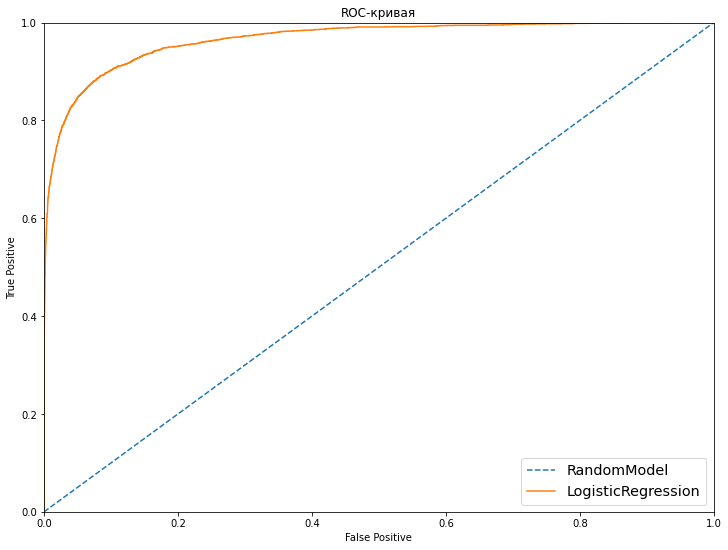

In [24]:
plt.figure(figsize=[12,9])
plt.plot([0, 1], [0, 1], linestyle='--', label='RandomModel')

classificator = LogisticRegression()
classificator.set_params(**LR_best_params)
classificator.fit(features_train, target_train)
probabilities_test = classificator.predict_proba(features_test)
probabilities_one_test = probabilities_test[:, 1]
fpr, tpr, thresholds = roc_curve(target_test, probabilities_one_test)
predict_test = classificator.predict(features_test)
plt.plot(fpr, tpr, label='LogisticRegression')
print('Метрики LogisticRegression')
print('ROC AUC:', roc_auc_score(target_test, probabilities_one_test))
print('F1:', f1_score(target_test, predict_test))
print('Precision:', precision_score(target_test, predict_test))
print('Recall:', recall_score(target_test, predict_test))
print('Accuracy:', accuracy_score(target_test, predict_test))
print()

plt.xlim([0,1])
plt.ylim([0,1])

plt.xlabel("False Positive")
plt.ylabel("True Positive")

plt.legend(loc='lower right', fontsize='x-large')

plt.title("ROC-кривая")
plt.show()


            1)Подготовленны данные обучения на моделях.
            2)Выбран способ баланса классов и поделены данные на обучающую, валидационную и тестовою выборку.
            3)Обучены модели и выбраны лучшие из них на валидационной выборке.
            4)Показаны параметры качества моделей.

        Если LogisticRegression и DecisionTreeClassifier обучались меньше 1 минуты, то CatBoostClassifier около 40 минут. F1 на Cv и на валидации больше 0.75 только у LogisticRegression (лучшие параметры {'C': 10, 'class_weight': {0: 1, 1: 8.834884437596301}, 'solver': 'lbfgs'}). Причем у данной модели высокие показатели аccuracy.
        Наихудшие показатели F1 у DecisionTreeClassifier, а у CatBoostClassifier f1 почти близка на валидации к нужному  для нас значению.